**Aluno: Raphael Friederich Ribeiro Filho** <br>
**E-mail: rfrf@cesar.school**

# CRISP-DM na Prática: Previsão de Churn em Plataforma de Streaming

Notebook para implementar o ciclo de vida de um projeto de Data Science, seguindo a metodologia **CRISP-DM** (Cross-Industry Standard Process for Data Mining).

Utilizaremos um conjunto de dados simulado de uma plataforma de streaming de música para prever quais usuários têm maior probabilidade de cancelar sua assinatura (churn).

## Fase 1: Entendimento do Negócio

Preencha com uma descrição do problema de negócio e como o modelo de previsão pode ser usado para atacar o problema. Explique como o desempenho do modelo influencia as KPIs do negócio.

## Fase 2: Entendimento dos Dados

Nesta fase, exploramos o conjunto de dados para entender sua estrutura, qualidade e distribuição. Buscamos por valores faltantes, tipos de dados inconsistentes e a distribuição das variáveis.

Crie uma conta no Kaggle e baixe o dataset para realizar a Atividade 1: https://www.kaggle.com/datasets/barun2104/telecom-churn


In [1]:
!curl -L -o /content/telecom-churn.zip https://www.kaggle.com/api/v1/datasets/download/barun2104/telecom-churn
!unzip /content/telecom-churn.zip -d /content/

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 46575  100 46575    0     0  92137      0 --:--:-- --:--:-- --:--:-- 92137
Archive:  /content/telecom-churn.zip
  inflating: /content/telecom_churn.csv  


In [2]:
import pandas as pd

df = pd.read_csv('/content/telecom_churn.csv')

print("Dataset baixado e carregado com sucesso!")

Dataset baixado e carregado com sucesso!


In [3]:
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


Para prever se usuario irá sair da plataforma e cancelar sua assinatura (Churn) e necessário entender que é um exemplo de modelo de classificação, pois queremos saber se sim ou não.
1. Identificar os tipos das colunas (String, inteiro, data etc)
2. Ver se tem valores nulos

## Fase 3: Preparação dos Dados

Agora, preparamos os dados para a modelagem. Isso inclui a limpeza de dados, a transformação de variáveis e a criação de novas features (Engenharia de Features) para treinar o modelo.

A saída deve ser um novo arquivo CSV para treinamento do modelo.

In [4]:
df.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


In [5]:
# Verificando a tipagem das colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [6]:
# Verificando quais colunas tem valores nulos
df.isnull().sum()

,0
Churn,0
AccountWeeks,0
ContractRenewal,0
DataPlan,0
DataUsage,0
CustServCalls,0
DayMins,0
DayCalls,0
MonthlyCharge,0
OverageFee,0


In [7]:
# Identificando quantos valores são Sim e Não para Churn
df['Churn'].value_counts()

,count
Churn,
0,2850
1,483


In [8]:
# Identificar Duplicados
print(df.duplicated().any())
print(df[df.duplicated()])

False
Empty DataFrame
Columns: [Churn, AccountWeeks, ContractRenewal, DataPlan, DataUsage, CustServCalls, DayMins, DayCalls, MonthlyCharge, OverageFee, RoamMins]
Index: []


In [9]:
# Bibliotecas necessárias ao longo do desenvolvimento
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [10]:
colunas = df.select_dtypes(include=['number']).columns
df.select_dtypes(include=['number']).columns


Index(['Churn', 'AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage',
       'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee',
       'RoamMins'],
      dtype='object')

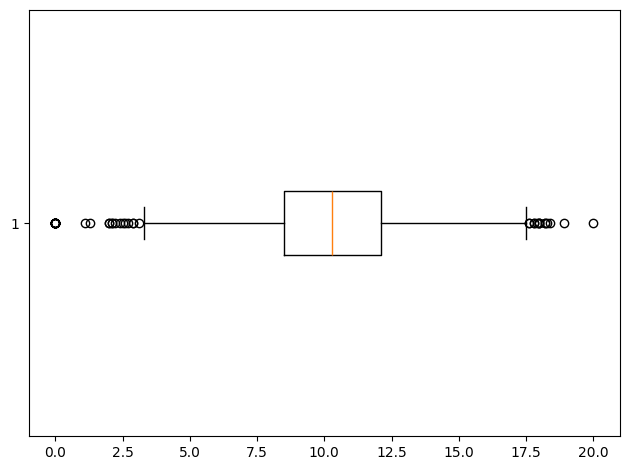

In [11]:
plt.boxplot(df['RoamMins'].values, vert=False)
plt.tight_layout()
plt.show()

In [12]:
# Como as colunas Churn, ContractRenewal e DataPlan são categóricas, não precisam analisar via Boxplot
cols = ['AccountWeeks', 'DataUsage', 'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge',
        'OverageFee', 'RoamMins']

/tmp/ipython-input-4073009054.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df[cols].values, labels=cols, vert=False)


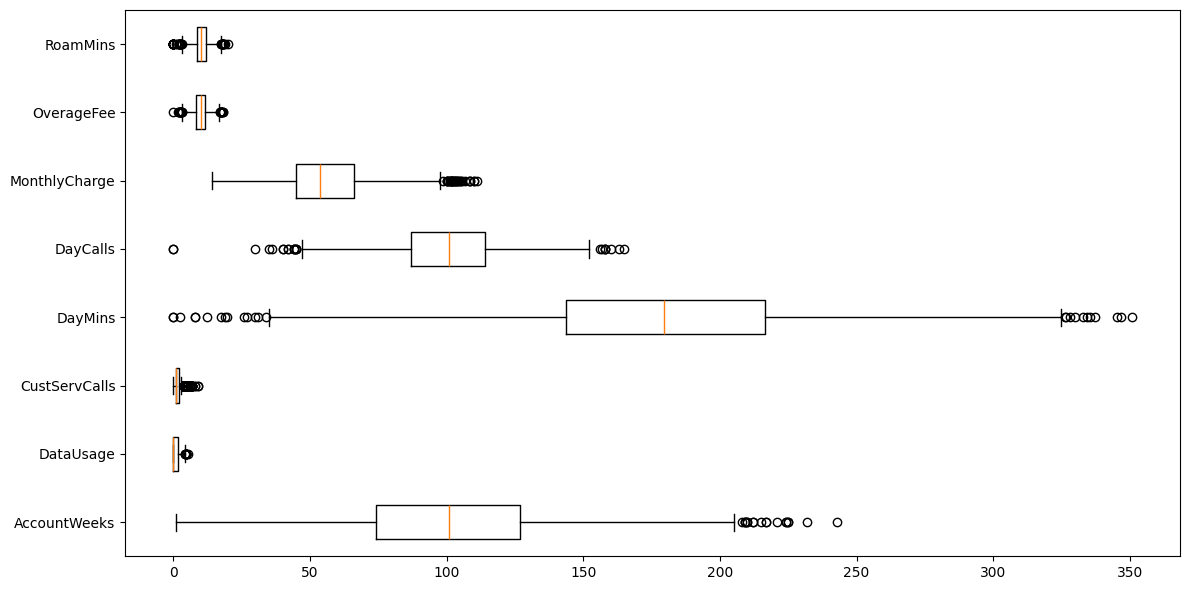

In [13]:
plt.figure(figsize=(12, 6))
plt.boxplot(df[cols].values, labels=cols, vert=False)
plt.tight_layout()
plt.show()

Foi visto que não há necessidades de aplicar cortes em registros considerados outliers, pois isso reflete o comportamento normal do usuário.

In [14]:
# Necessário ver a taxa média de Churns
df['Churn'].value_counts()

taxa_med_churn = df['Churn'].mean() * 100
print(f"Taxa média de Churn: {taxa_med_churn:.2f}%")

Taxa média de Churn: 14.49%


In [15]:
df.groupby('Churn')['AccountWeeks'].mean()

,AccountWeeks
Churn,
0,100.793684
1,102.664596


In [16]:
# Dividir em grupo de Churn e Não Churn
g_churn = df[df['Churn']==1]
g_N_churn = df[df['Churn']==0]

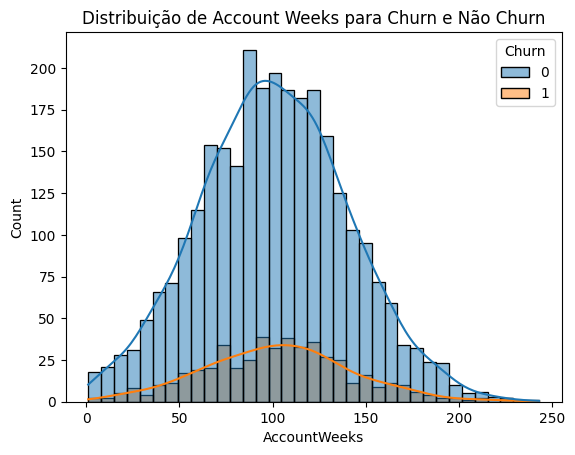

In [17]:
# Média de AccountWeeks de churn e não churn
sns.histplot(data=df, x='AccountWeeks', hue='Churn', kde=True)
plt.title('Distribuição de Account Weeks para Churn e Não Churn')
plt.show()

É possível ver pelo gráfico que independente de Churn e Não Churn, temos uma maior quantidade de clientes que estão na empresa de 50 a 150 semanas. Ou seja, o churn acontece em todas as faixas de tempo de utilização de empresa, a gente só ver um número maior dentro desse intervalo por que temos mais clientes utilizando nessa faixa, mas não necessariamente representa que dentro dessa faixa a uma probabilidade de ter churn do que clintes novos (De 0 a 50) ou clientes antigos (150 ou mais) quanto maior a quantidade de clientes, maior o Churn

In [18]:
med_data_usage_churn = df[df['Churn'] == 1]['DataUsage'].mean()
med_data_usage_n_churn = df[df['Churn'] == 0]['DataUsage'].mean()

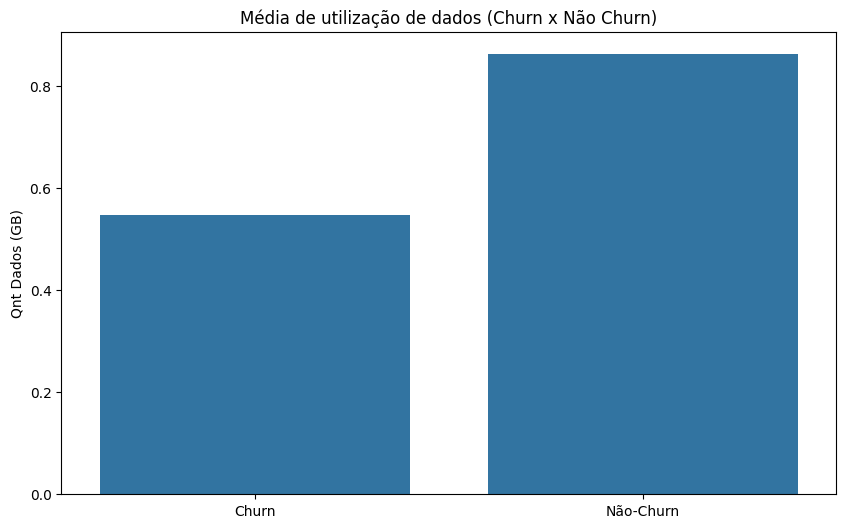

In [19]:
# Utilização média de dados por Churn x Não Churn
plt.figure(figsize=(10,6))
sns.barplot(x=['Churn', 'Não-Churn'], y=[med_data_usage_churn, med_data_usage_n_churn])
plt.title('Média de utilização de dados (Churn x Não Churn)')
plt.ylabel('Qnt Dados (GB)')
plt.show()

Nesse gráfico podemos ver que nos usuários que realizaram o Churn, consumiram levemente menos dados que as pessoas que não realizaram o Churn. Pode ser algum indicativo, mas não conclusivo. É preciso de outra análise para ter mais resposta.

In [20]:
med_DayMins_churn = df[df['Churn'] == 1]['DayMins'].mean()
med_DayMins_n_churn = df[df['Churn'] == 0]['DayMins'].mean()

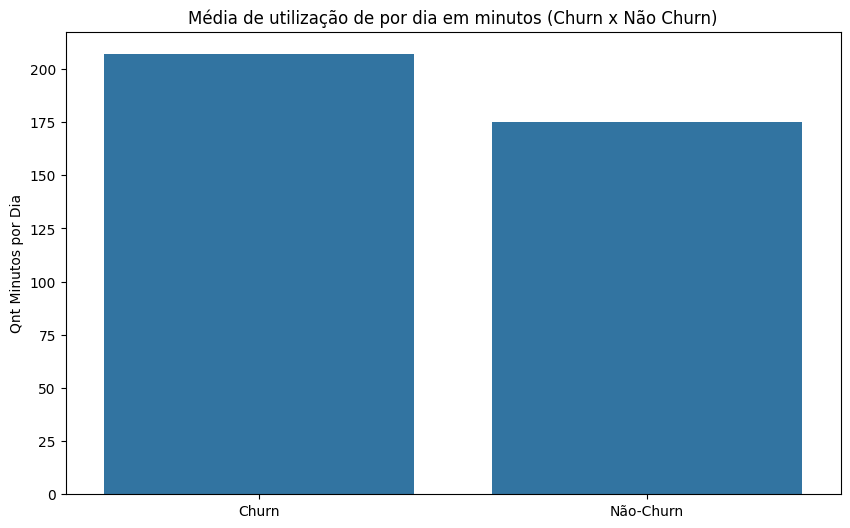

In [21]:
# Utilização média de uso por dia em minutos por Churn x Não Churn
plt.figure(figsize=(10,6))
sns.barplot(x=['Churn', 'Não-Churn'], y=[med_DayMins_churn, med_DayMins_n_churn])
plt.title('Média de utilização de por dia em minutos (Churn x Não Churn)')
plt.ylabel('Qnt Minutos por Dia')
plt.show()

Nada conclusivo quando se ver a utilização média do plano por dia em minutos. Ambos tem a quantidade muito próximas do grupo que realizaram Churn ou não.

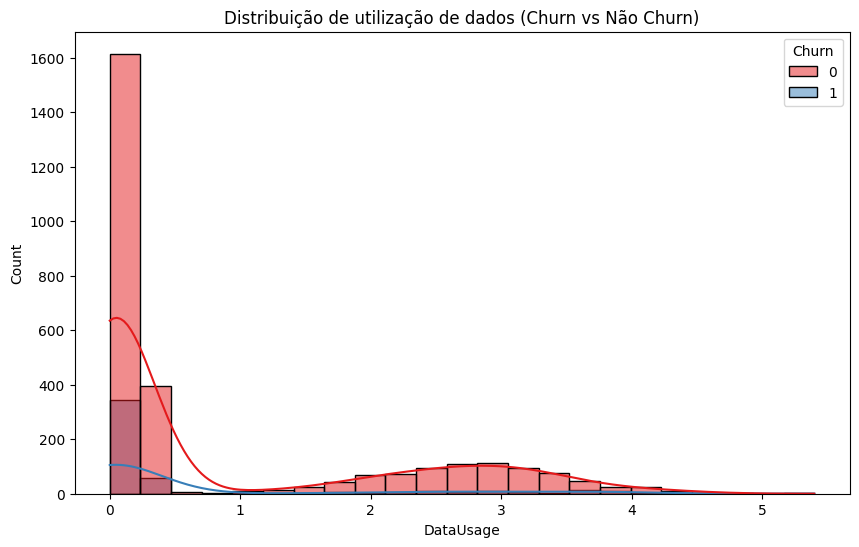

In [22]:
# Distribuição de utilização de dados (Churn vs Não Churn)
plt.figure(figsize=(10, 6))
sns.histplot(x='DataUsage', hue='Churn', data=df, kde=True, palette='Set1')
plt.title('Distribuição de utilização de dados (Churn vs Não Churn)')
plt.show()

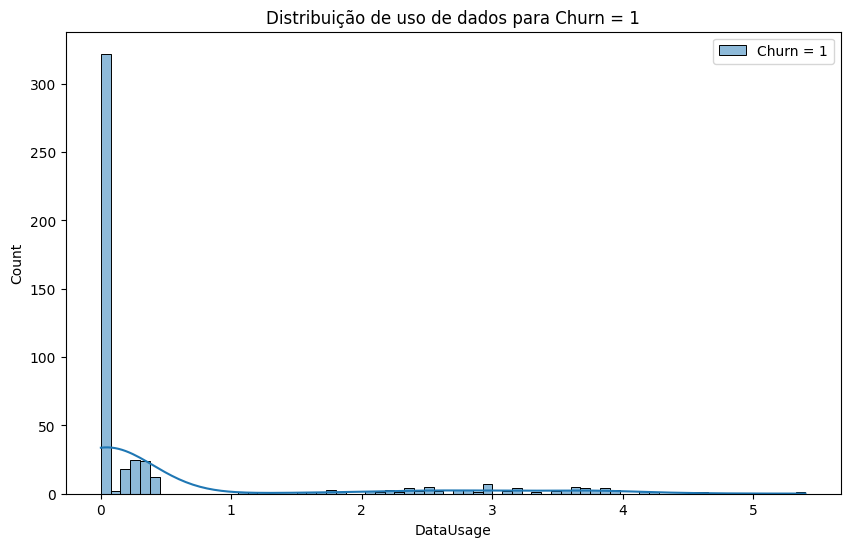

In [23]:
# Distribuição de utilização de dados para Churn
plt.figure(figsize=(10, 6))
sns.histplot(x='DataUsage', data=df[df['Churn'] == 1], kde=True, label='Churn = 1')
plt.title('Distribuição de uso de dados para Churn = 1')
plt.legend()
plt.show()

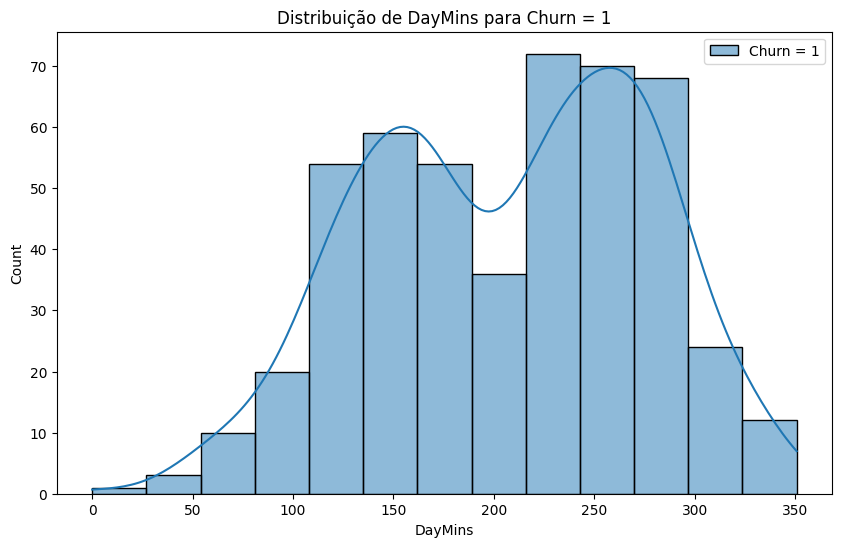

In [24]:
# Distribuição de DayMins para Churn
plt.figure(figsize=(10, 6))
sns.histplot(x='DayMins', data=df[df['Churn'] == 1], kde=True, label='Churn = 1')

plt.title('Distribuição de DayMins para Churn = 1')
plt.legend()
plt.show()

Nota-se a partir do gráfico que temos uma grande utilização na faixa de 125 até 300, tendo uma leve queda em 200.

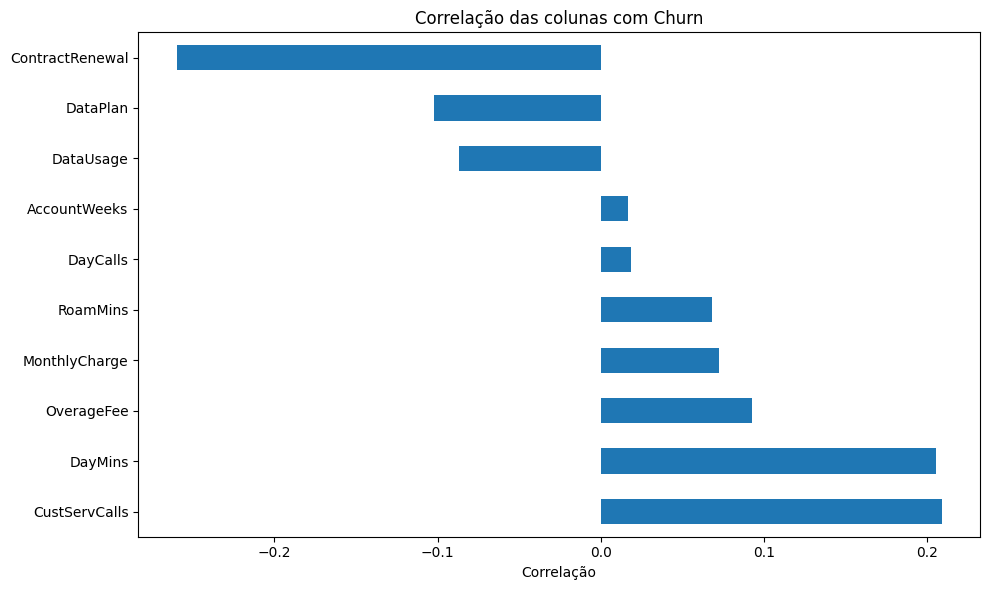

In [25]:
# Visualizar correlação das colunas com a target (Churn)
correlation_with_churn = df.corr()['Churn'].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
correlation_with_churn.drop('Churn').plot(kind='barh')
plt.title('Correlação das colunas com Churn')
plt.xlabel('Correlação')
plt.tight_layout()
plt.show()

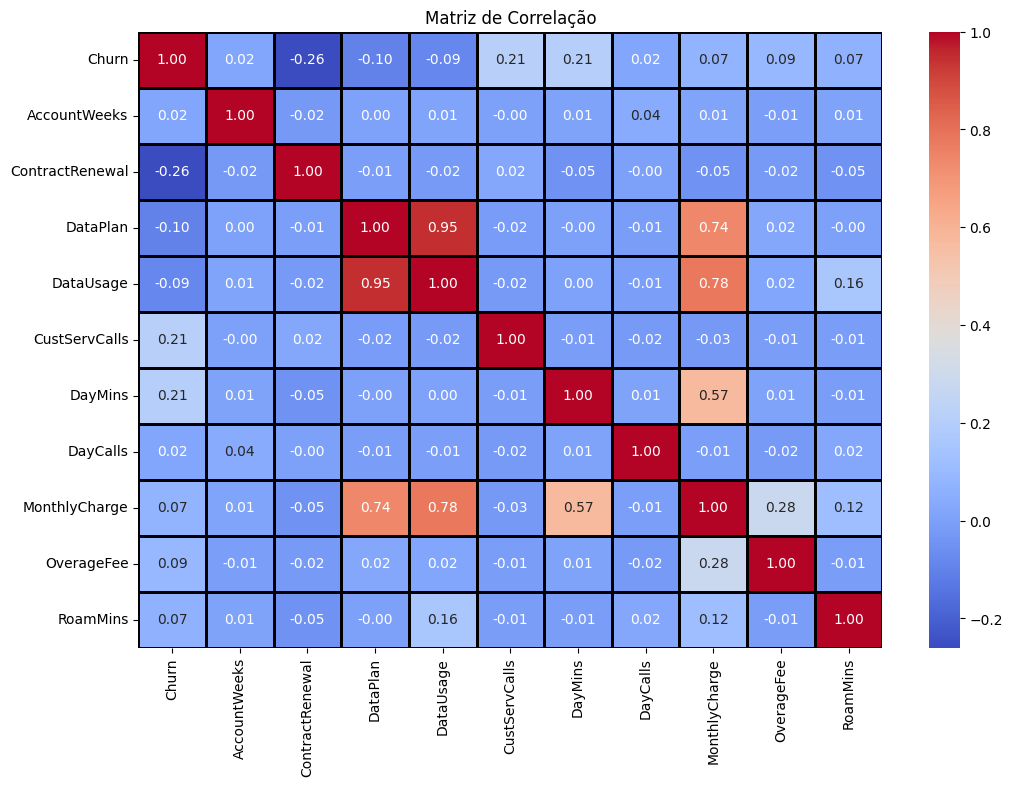

In [26]:
# Correlação entre as colunas
matriz_correlacao = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap="coolwarm", linewidths=1, linecolor='black')
plt.title('Matriz de Correlação')
plt.show()

Foram vistos 3 relações fortes entre as colunas. Sendo elas: DataUsage com DataPlan de 0.95; MonthlyCharge com DataPlan de 0.74; MonthlyCharge com DataUsage de 0.78. Já na relação de MonthlyCharge com DayMins foi uma relação média marcando apenas 0.57.<br>
Ou seja, Faz sentido o usuário ter uma despesa maior no mês (MonthlyCharge) por que o plano dele ofereçe mais dados, e consequentemente se ele usar mais dados, ele vai precisar de um plano de dados que o atenda. Mas essas relações não acrescetam muito na análise de Churns. Logo, vi necessidade de criar 3 features sendo eles: CustoDadoUsado, PlanoDadosNaoUsado e UsoDadosSemPlano para treinar o modelo.

In [27]:
# Criando o df_final para treinar o modelo
df_final = df.copy()

In [28]:
# Criação da Feature Custo por dado usado
df_final['CustoDadoUsado'] = df_final.apply(
    lambda row: row['MonthlyCharge'] / row['DataUsage']
                if row['DataUsage'] > 0.5
                else 0,
    axis=1)

In [29]:
# Tem plano de dados mas não usa (desperdício)
df_final['PlanoDadosNaoUsado'] = ((df_final['DataPlan'] == 1) & (df_final['DataUsage'] < 1)).astype(int)

# Usa dados sem ter plano (pode estar pagando caro)
df_final['UsoDadosSemPlano'] = ((df_final['DataPlan'] == 0) & (df_final['DataUsage'] > 0)).astype(int)

A ideia das features criadas é poder enxergar algum tipo de inconsistências de uso de plano inadequado, também analisar a eficiência de custo, pois podem indicar clientes insatisfeitos com preço. Essas features podem capturar padrões não-lineares que nem sempre apenas as correlações simples não mostram.

In [34]:
df_final

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins,CustoDadoUsado,PlanoDadosNaoUsado,UsoDadosSemPlano
0,0,128,1,1,2.70,1,265.1,110,89.0,9.87,10.0,32.962963,0,0
1,0,107,1,1,3.70,1,161.6,123,82.0,9.78,13.7,22.162162,0,0
2,0,137,1,0,0.00,0,243.4,114,52.0,6.06,12.2,0.000000,0,0
3,0,84,0,0,0.00,2,299.4,71,57.0,3.10,6.6,0.000000,0,0
4,0,75,0,0,0.00,3,166.7,113,41.0,7.42,10.1,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,0,192,1,1,2.67,2,156.2,77,71.7,10.78,9.9,26.853933,0,0
3329,0,68,1,0,0.34,3,231.1,57,56.4,7.67,9.6,0.000000,0,1
3330,0,28,1,0,0.00,2,180.8,109,56.0,14.44,14.1,0.000000,0,0
3331,0,184,0,0,0.00,2,213.8,105,50.0,7.98,5.0,0.000000,0,0


In [ ]:
# df_final.to_csv('df_final_para_treinamento.csv', index=False)

## Fase 4: Modelagem

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separando a target das features em X e y
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# Separando em treino e teste antes de padronizar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [36]:
# Padronização - Fit no treino, transform em teste e treino
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
# Regressão Logistica - Criando o modelo
from sklearn.linear_model import LogisticRegression
model_log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Modelo treinado
model_log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [38]:
# Random Forest - Criando o modelo
from sklearn.ensemble import RandomForestClassifier
model_rand_for = RandomForestClassifier(random_state=42, n_estimators=100)

# Modelo treinado
model_rand_for.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [39]:
# XGBoost - Criando o modelo
import xgboost as xgb
model_xgb = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# Modelo treinado
model_xgb.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## Fase 5: Avaliação

In [40]:
# Importando bibliotecas para Avaliação
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [41]:
# Avaliação (Regressão Logistica)
y_pred_log_reg = model_log_reg.predict(X_test_scaled)

print("=== Regressão Logistica ===")
print("Acurácia:", accuracy_score(y_test, y_pred_log_reg))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_log_reg))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_log_reg))

=== Regressão Logistica ===
Acurácia: 0.8605697151424287

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       570
           1       0.55      0.22      0.31        97

    accuracy                           0.86       667
   macro avg       0.72      0.59      0.62       667
weighted avg       0.83      0.86      0.83       667


Matriz de Confusão:
[[553  17]
 [ 76  21]]


In [42]:
# Avaliação (Random Forest)
y_pred_rand_for = model_rand_for.predict(X_test_scaled)

print("=== Random Forest ===")
print("Acurácia:", accuracy_score(y_test, y_pred_rand_for))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_rand_for))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rand_for))

=== Random Forest ===
Acurácia: 0.9265367316341829

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       570
           1       0.82      0.63      0.71        97

    accuracy                           0.93       667
   macro avg       0.88      0.80      0.84       667
weighted avg       0.92      0.93      0.92       667


Matriz de Confusão:
[[557  13]
 [ 36  61]]


In [43]:
# Avaliação (XGBoost)
y_pred_xgb = model_xgb.predict(X_test_scaled)

print("=== XGBoost ===")
print("Acurácia:", accuracy_score(y_test, y_pred_xgb))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_xgb))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_xgb))

=== XGBoost ===
Acurácia: 0.9160419790104948

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       570
           1       0.75      0.63      0.69        97

    accuracy                           0.92       667
   macro avg       0.85      0.80      0.82       667
weighted avg       0.91      0.92      0.91       667


Matriz de Confusão:
[[550  20]
 [ 36  61]]


O melhor desempenho foi o Random Forest, pois ele além de ter uma melhor acuracia e precisão, ele tem uma boa porcentagem de recall, pois ele vai capturar quem vai sair.

## Fase 6: Implantação e Monitoramento:

Para a fase de implantação, devido ao que foi visto nos estudos acima. A empresa para evitar o Churn pode focar em atacar em clientes a partir desses 4 indicadores abaixo:

INDICADOR CRÍTICO 1: Reclamações ao Suporte (CustServCalls)
<br>
. Correlação: +0.21 (mais forte)<br>
. Clientes com 3+ reclamações: 26.15% de churn<br>
. Clientes com <3 reclamações: 11.41% de churn;<br>
. IMPACTO: 2.3x mais churn!;<br>
<br>
INDICADOR CRÍTICO 2: Renovação de Contrato (ContractRenewal)
<br>
. Correlação: -0.26 (protetor mais forte!)<br>
. Clientes que renovam: 93% ficam<br>
. Clientes que NÃO renovam: 72% ficam<br>
. IMPACTO: Não renovar = 21pp mais churn.<br>
<br>
INDICADOR IMPORTANTE 3: Uso Intensivo + Insatisfação (DayMins + CustServCalls)
<br>
. DayMins correlação: +0.21<br>
. Heavy users (>200 min) que reclamam: ALTO RISCO<br>
. Feature engineered "HighCost_HighComplaints": captura sinergia<br>
<br>
Observação:
Heavy users deveriam ser clientes ideais, mas estão insatisfeitos. Isso indica plano inadequado ou problemas de qualidade.<br>
<br>
INDICADOR IMPORTANTE 4: Plano de Dados Inadequado (DataPlan/DataUsage)
<br>
. DataPlan correlação: -0.10 (protetor leve)<br>
. DataUsage correlação: -0.09<br>
. Clientes Churn: 17% têm plano de dados<br>
. Clientes Não-Churn: 30% têm plano de dados<br>
. IMPACTO: Quem tem plano churn 43% menos!<br>
<br>
Observação:
Clientes sem plano de dados são menos engajados e maior churn. Oferecer um plano adequado pode aumentar engajamento.